<a href="https://colab.research.google.com/github/rimakrivis/lab-image-classification-using-convolutional-neural-networks/blob/main/main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab : Image Classification using Convolutional Neural Networks

At the end of this laboratory, you would get familiarized with

*   Creating deep networks using Keras
*   Steps necessary in training a neural network
*   Prediction and performance analysis using neural networks

---

# **In case you use a colaboratory environment**
By default, Colab notebooks run on CPU.
You can switch your notebook to run with GPU.

In order to obtain access to the GPU, you need to choose the tab Runtime and then select “Change runtime type” as shown in the following figure:

![Changing runtime](https://miro.medium.com/max/747/1*euE7nGZ0uJQcgvkpgvkoQg.png)

When a pop-up window appears select GPU. Ensure “Hardware accelerator” is set to GPU.

# **Working with a new dataset: CIFAR-10**

The CIFAR-10 dataset consists of 60000 32x32 colour images in 10 classes, with 6000 images per class. There are 50000 training images and 10000 test images. More information about CIFAR-10 can be found [here](https://www.cs.toronto.edu/~kriz/cifar.html).

In Keras, the CIFAR-10 dataset is also preloaded in the form of four Numpy arrays. x_train and y_train contain the training set, while x_test and y_test contain the test data. The images are encoded as Numpy arrays and their corresponding labels ranging from 0 to 9.

Your task is to:

*   Visualize the images in CIFAR-10 dataset. Create a 10 x 10 plot showing 10 random samples from each class.
*   Convert the labels to one-hot encoded form.
*   Normalize the images.




In [2]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical

# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


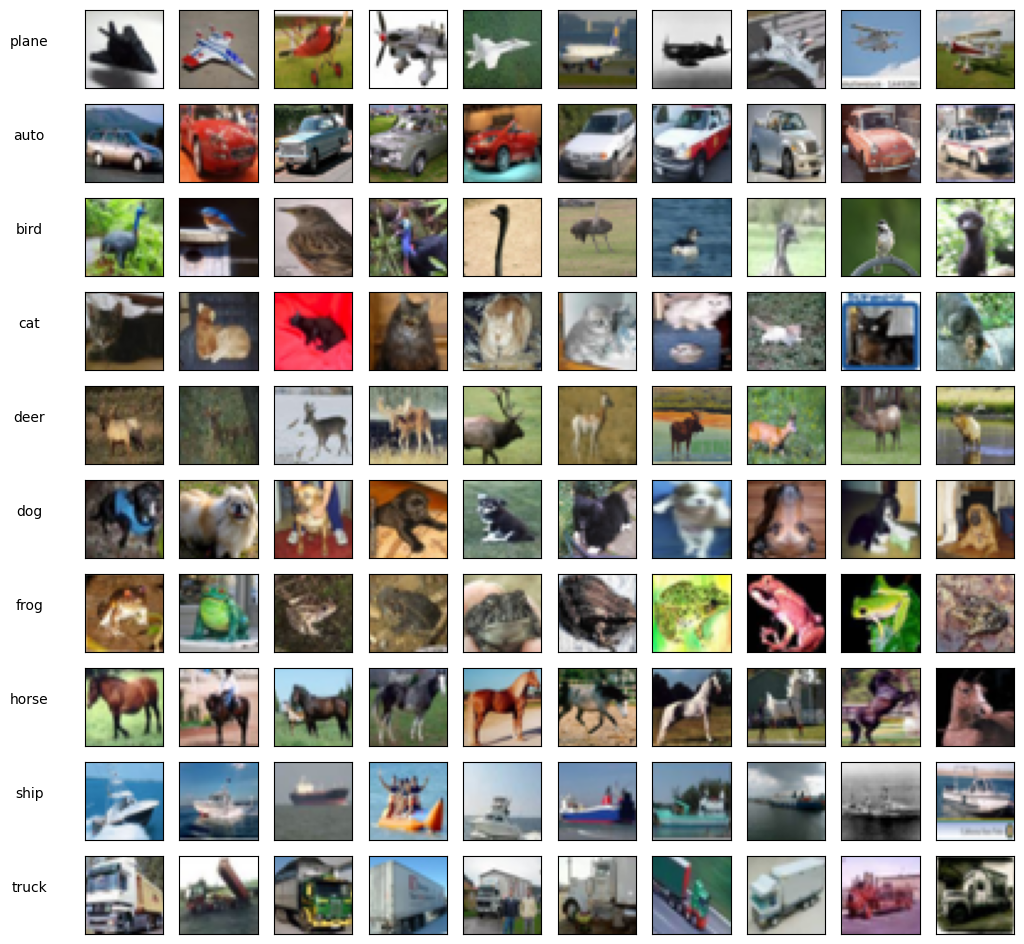

In [3]:
class_names = ['plane', 'auto', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

plt.figure(figsize=(12,12))

for i in range(10):
  indices = np.where(y_train == i)[0]

  for j in range(10):
    plt.subplot(10,10,i*10 + j + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[indices[j]])
    if j == 0:
            # Add class name as label on the left
            plt.ylabel(class_names[i], rotation=0, labelpad=40)

plt.show()



In [4]:
num_classes = 10
y_train_cat = to_categorical(y_train, num_classes)
y_test_cat = to_categorical(y_test, num_classes)

print(f"Original label: {y_train[0]}")
print(f"One-hot form: {y_train_cat[0]}")

Original label: [6]
One-hot form: [0. 0. 0. 0. 0. 0. 1. 0. 0. 0.]


In [5]:
# Scale pixel values to [0, 1] range
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

print("Normalization complete.")
print(f"New pixel range: {x_train.min()} to {x_train.max()}")

Normalization complete.
New pixel range: 0.0 to 1.0


## Define the following model (same as the one in tutorial)

For the convolutional front-end, start with a single convolutional layer with a small filter size (3,3) and a modest number of filters (32) followed by a max pooling layer.

Use the input as (32,32,3).

The filter maps can then be flattened to provide features to the classifier.

Use a dense layer with 100 units before the classification layer (which is also a dense layer with softmax activation).

In [29]:
from keras.backend import clear_session
clear_session()

In [30]:
from keras.src import activations
from keras.src.models import model
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()
model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(32, 32, 3)))
model.add(layers.MaxPooling2D((2,2)))
model.add(layers.Flatten())
model.add(layers.Dense(100, activation='relu'))
model.add(layers.Dense(10, activation='softmax'))
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 7200)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 100)            │       720,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 722,006 (2.75 MB)

 Trainable params: 722,006 (2.75 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [31]:
# Compile the model
model.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

# Train the model
history = model.fit(
    x_train, y_train_cat,
    epochs=50,
    batch_size=512,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - accuracy: 0.2118 - loss: 2.2305 - val_accuracy: 0.2559 - val_loss: 2.1606
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.2808 - loss: 2.0944 - val_accuracy: 0.2958 - val_loss: 2.0359
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.3107 - loss: 1.9915 - val_accuracy: 0.3236 - val_loss: 1.9513
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3334 - loss: 1.9242 - val_accuracy: 0.3458 - val_loss: 1.8947
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3481 - loss: 1.8783 - val_accuracy: 0.3535 - val_loss: 1.8610
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3602 - loss: 1.8436 - val_accuracy: 0.3454 - val_loss: 1.8518
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3713 - loss: 1.8177 - val_accuracy: 0.3548 - val_loss: 1.8185
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.3800 - loss: 1.7920 - val_accuracy: 0.3755 - v

In [39]:
model.save("history.keras")

In [42]:
import keras
loaded_model = keras.saving.load_model("/content/history.keras")

*   Plot the cross entropy loss curve and the accuracy curve

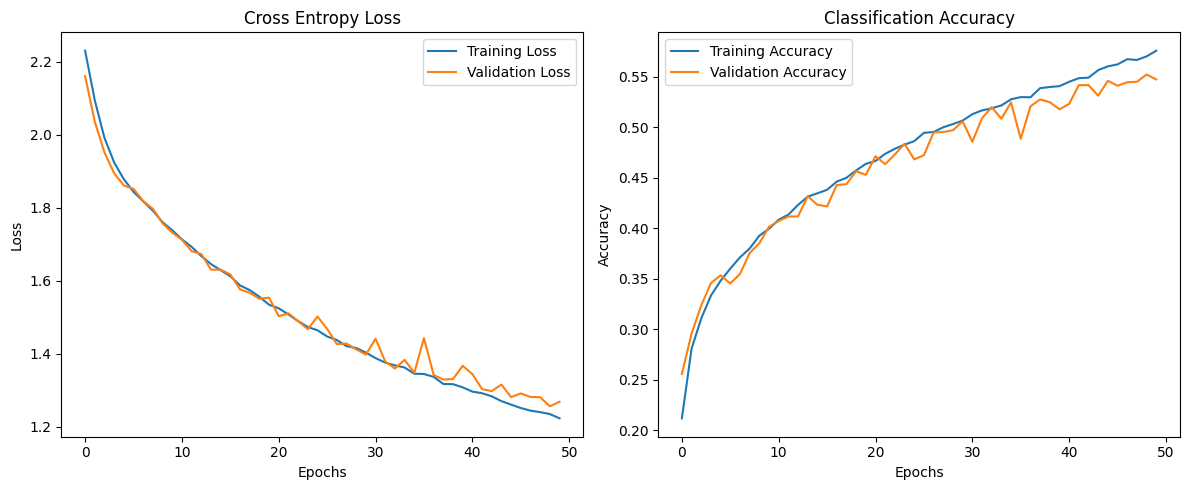

In [32]:
import matplotlib.pyplot as plt


plt.figure(figsize=(12, 5))

# Plot Cross Entropy Loss
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Cross Entropy Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

# Plot Accuracy
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Classification Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

## Defining Deeper Architectures: VGG Models

*   Define a deeper model architecture for CIFAR-10 dataset and train the new model for 50 epochs with a batch size of 512. We will use VGG model as the architecture.

Stack two convolutional layers with 32 filters, each of 3 x 3.

Use a max pooling layer and next flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input


In [33]:
from keras.backend import clear_session
clear_session()

In [34]:
from tensorflow.keras import layers, models

model_vgg = models.Sequential([
    layers.Input(shape=(32, 32, 3)),


    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),


    layers.Dense(128, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model_vgg.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,060,138 (4.04 MB)

 Trainable params: 1,060,138 (4.04 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 50 epochs with a batch size of 512.

In [35]:
#Compile the model

model_vgg.compile(
    optimizer='sgd',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

#Train the model
history_vgg = model_vgg.fit(
    x_train, y_train_cat,
    epochs=50,
    batch_size=512,
    validation_data=(x_test, y_test_cat),
    verbose=1
)

Epoch 1/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 6s 47ms/step - accuracy: 0.1868 - loss: 2.2221 - val_accuracy: 0.2250 - val_loss: 2.1496
Epoch 2/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2521 - loss: 2.0914 - val_accuracy: 0.2889 - val_loss: 2.0321
Epoch 3/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.2985 - loss: 2.0023 - val_accuracy: 0.2987 - val_loss: 2.0194
Epoch 4/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step - accuracy: 0.3278 - loss: 1.9203 - val_accuracy: 0.3431 - val_loss: 1.8717
Epoch 5/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3547 - loss: 1.8566 - val_accuracy: 0.3561 - val_loss: 1.8365
Epoch 6/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3697 - loss: 1.8173 - val_accuracy: 0.3778 - val_loss: 1.7788
Epoch 7/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 26ms/step - accuracy: 0.3858 - loss: 1.7712 - val_accuracy: 0.3802 - val_loss: 1.7639
Epoch 8/50
98/98 ━━━━━━━━━━━━━━━━━━━━ 3s 29ms/step - accuracy: 0.3929 - loss: 1.7366 - val_accuracy: 0.3841 - v

In [44]:
model.save("history_vgg.keras")

*   Compare the performance of both the models by plotting the loss and accuracy curves of both the training steps. Does the deeper model perform better? Comment on the observation.


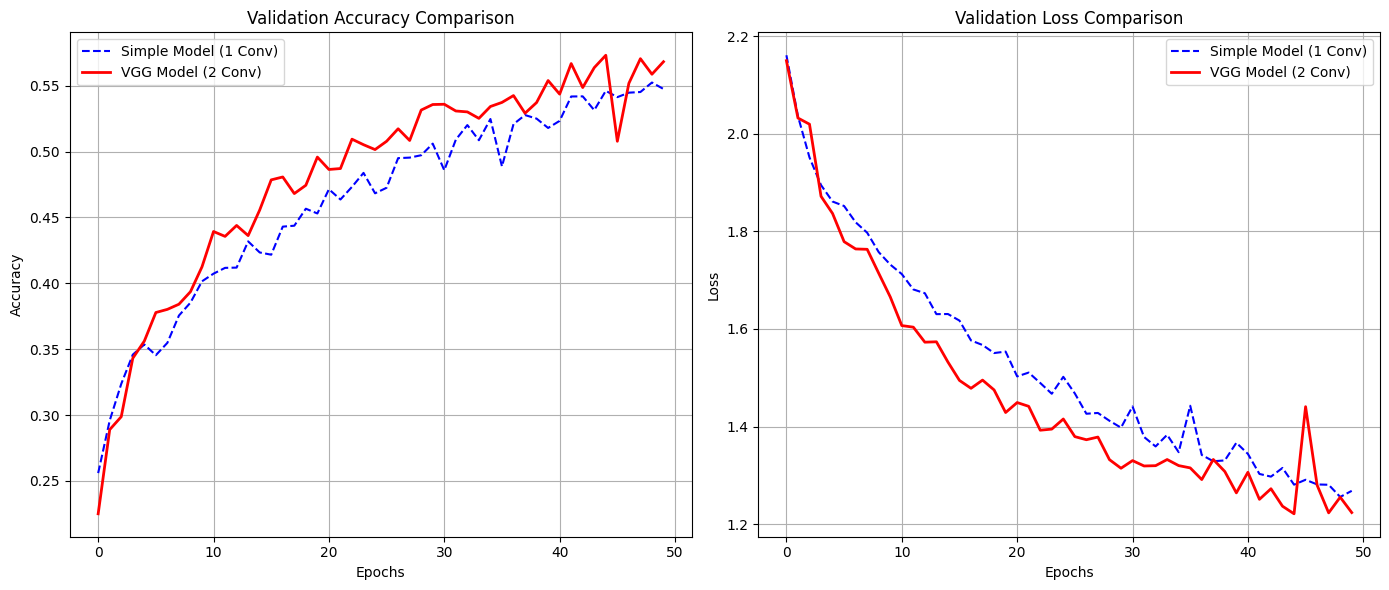

In [36]:
import matplotlib.pyplot as plt

# 1. Create a figure with two plots
plt.figure(figsize=(14, 6))

# Plot Validation Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['val_accuracy'], label='Simple Model (1 Conv)', color='blue', linestyle='--')
plt.plot(history_vgg.history['val_accuracy'], label='VGG Model (2 Conv)', color='red', linewidth=2)
plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

# Plot Validation Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['val_loss'], label='Simple Model (1 Conv)', color='blue', linestyle='--')
plt.plot(history_vgg.history['val_loss'], label='VGG Model (2 Conv)', color='red', linewidth=2)
plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



**Comment on the observation**

*(Double-click or enter to edit)*

VGG model outperformed the simple model, because the additional convolutional layer allowed more complex lerning of the image features. It has higher accuracy and lower loss.

*   Use predict function to predict the output for the test split
*   Plot the confusion matrix for the new model and comment on the class confusions.


313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


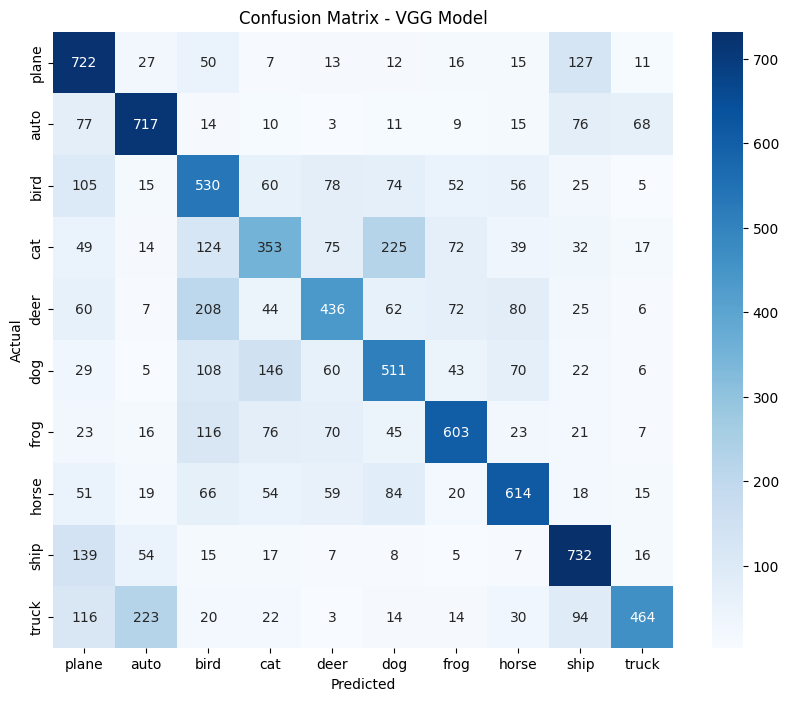

In [47]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

y_pred = model_vgg.predict(x_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test_cat, axis=1)

cm = confusion_matrix(y_true, y_pred_classes)

class_names = ['plane', 'auto', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - VGG Model')
plt.show()


**Comment here :**

*(Double-click or enter to edit)*

the model is most successful at identifying ships and planes, however  i'ts not great with distinguishing cat and dogs, also bird and deers. This suggest that the model doing well with the shapes, but less good with fine grained animal features in low resolution.

*    Print the test accuracy for the trained model.

In [49]:
test_loss, test_accuracy = model_vgg.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Accuracy: {test_accuracy :.2%}")
print(f"Test Loss: {test_loss:4f}")

Test Accuracy: 56.82%
Test Loss: 1.223888


## Define the complete VGG architecture.

Stack two convolutional layers with 64 filters, each of 3 x 3 followed by max pooling layer.

Stack two more convolutional layers with 128 filters, each of 3 x 3, followed by max pooling, followed by two more convolutional layers with 256 filters, each of 3 x 3, followed by max pooling.

Flatten the output of the previous layer and add a dense layer with 128 units before the classification layer.

For all the layers, use ReLU activation function.

Use same padding for the layers to ensure that the height and width of each layer output matches the input

*   Change the size of input to 64 x 64.

In [50]:
from keras.backend import clear_session
clear_session()

In [52]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense

model_vgg_complete = Sequential([
    Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=(64, 64, 3)),
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation='relu', padding='same'),
    Conv2D(128, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation='relu', padding='same'),
    Conv2D(256, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

model_vgg_complete.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     2,097,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,243,978 (12.37 MB)

 Trainable params: 3,243,978 (12.37 MB)

 Non-trainable params: 0 (0.00 B)

*   Compile the model using categorical_crossentropy loss, SGD optimizer and use 'accuracy' as the metric.
*   Use the above defined model to train CIFAR-10 and train the model for 10 epochs with a batch size of 512.
*   Predict the output for the test split and plot the confusion matrix for the new model and comment on the class confusions.

In [53]:
import tensorflow as tf

x_train_64 = tf.image.resize(x_train, (64, 64))
x_test_64 = tf.image.resize(x_test, (64, 64))



Resizing images... This might take a minute.


In [54]:
# Compile
model_vgg_complete.compile(
    loss='categorical_crossentropy',
    optimizer='sgd',
    metrics=['accuracy']
)

# Train
history_vgg_full = model_vgg_complete.fit(
    x_train_64, y_train_cat,
    epochs=10,
    batch_size=512,
    validation_data=(x_test_64, y_test_cat),
    verbose=1
)

Epoch 1/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 141s 1s/step - accuracy: 0.1219 - loss: 2.2964 - val_accuracy: 0.1476 - val_loss: 2.2888
Epoch 2/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 430ms/step - accuracy: 0.1598 - loss: 2.2695 - val_accuracy: 0.2067 - val_loss: 2.2303
Epoch 3/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 429ms/step - accuracy: 0.2164 - loss: 2.1655 - val_accuracy: 0.2010 - val_loss: 2.1632
Epoch 4/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 429ms/step - accuracy: 0.2577 - loss: 2.0913 - val_accuracy: 0.2774 - val_loss: 2.0479
Epoch 5/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 429ms/step - accuracy: 0.2945 - loss: 2.0024 - val_accuracy: 0.2993 - val_loss: 1.9696
Epoch 6/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 429ms/step - accuracy: 0.3237 - loss: 1.9220 - val_accuracy: 0.3497 - val_loss: 1.8337
Epoch 7/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 429ms/step - accuracy: 0.3488 - loss: 1.8461 - val_accuracy: 0.3659 - val_loss: 1.8173
Epoch 8/10
98/98 ━━━━━━━━━━━━━━━━━━━━ 42s 429ms/step - accuracy: 0.3676 - loss: 1.7866 - val_accura

In [55]:
model.save("history_vgg_full.keras")

# Understanding deep networks

*   What is the use of activation functions in network? Why is it needed?
*   We have used softmax activation function in the exercise. There are other activation functions available too. What is the difference between sigmoid activation and softmax activation?
*   What is the difference between categorical crossentropy and binary crossentropy loss?

**Write the answers below :**

1 - Use of activation functions:


Activation functions are used to introduce non-linearity into the model. Without them, a neural network is just a simple linear regression and cannot learn complex patterns from data like images. These functions decide if a neuron should "fire" or stay inactive based on the input it receives.
_

2 - Key Differences between sigmoid and softmax:

Sigmoid is used for binary classification. Softmax is used for multi-class classification . It makes sure the sum of all predicted probabilities is exactly 1.0 (100%), so the classes compete against each other.

_

3 - Key Differences between categorical crossentropy and binary crossentropy loss:

It is about how many classes you have. Binary crossentropy is used when you only have two groups. Categorical crossentropy is used for many groups, like our 10 categories. It calculates the error by checking how far the model's guess is from the real answer.

_
